#### 🎯 Definição do Problema:

**Problema 1** - Previsão de Risco de Crédito:  
📉 Desenvolver um modelo de machine learning para prever a probabilidade de inadimplência (`Risk_Flag`) com base em dados demográficos e financeiros dos clientes.

**Problema 2** - Análise de Fatores Determinantes:  
🔍 Identificar quais variáveis (renda, idade, profissão, etc.) têm maior correlação com o risco de crédito para orientar políticas de concessão.

#### 📊 Contexto do Negócio:
💸 O sistema financeiro enfrenta altas perdas com inadimplência. Um modelo preciso pode economizar milhões em créditos mal avaliados.

#### ⚙️ Abordagem Técnica:
```python
Algoritmos testados:
1. DecisionTreeClassifier
2. RandomForestClassifier  
3. KNeighborsClassifier
4. LogisticRegression
5. MLPClassifier

#### ⚙️ Instalando dependências: 

In [ ]:
# módulo para obtermos os dados diretamente do kaggle
!pip install kagglehub

import kagglehub
# Análise Exploratória e manipulação dos dados
import pandas as pd
import numpy as np
# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning (Pré-processamento)
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

# Machine Learning (Tuning de parametros)
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Machine Learning (Modelos)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from scipy.stats import uniform, randint


[notice] A new release of pip is available: 24.1 -> 25.1.1
[notice] To update, run: C:\Users\USER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### 📥 Coleta de dados: 
* Vamos obter os dados do Kaggle, através do seguinte link: https://www.kaggle.com/datasets/ethicalstar/loan-prediction

In [2]:
# Vamos obter os dados do site do Kaggle para nossa análise.
path = kagglehub.dataset_download("ethicalstar/loan-prediction")
print("Caminho do arquivo csv:", path)

# Carregando os dados em um dataframe.
table = pd.read_csv(filepath_or_buffer='Loan Prediction.csv')
df = pd.DataFrame(data=table)
df.head()

Caminho do arquivo csv: C:\Users\USER\.cache\kagglehub\datasets\ethicalstar\loan-prediction\versions\1


,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


####  🧹 Limpeza e pré-processamento dos dados:

In [3]:
# Verificando valores nulos
print(df.isnull().sum())
# Verificando valores duplicados
print('duplicados', df.duplicated(subset=df[:]).sum())
# Descartando colunas inúteis para a análise
df.drop(columns='Id',inplace=True)


Id                   0
Income               0
Age                  0
Experience           0
Married/Single       0
House_Ownership      0
Car_Ownership        0
Profession           0
CITY                 0
STATE                0
CURRENT_JOB_YRS      0
CURRENT_HOUSE_YRS    0
Risk_Flag            0
dtype: int64
duplicados 0


#### 🔍 Análise exploratória

* Estrutura dos dados

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Income             252000 non-null  int64 
 1   Age                252000 non-null  int64 
 2   Experience         252000 non-null  int64 
 3   Married/Single     252000 non-null  object
 4   House_Ownership    252000 non-null  object
 5   Car_Ownership      252000 non-null  object
 6   Profession         252000 non-null  object
 7   CITY               252000 non-null  object
 8   STATE              252000 non-null  object
 9   CURRENT_JOB_YRS    252000 non-null  int64 
 10  CURRENT_HOUSE_YRS  252000 non-null  int64 
 11  Risk_Flag          252000 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 23.1+ MB


* Descrições estatísticas das colunas númericas

In [6]:
# Alterando o formato da saída númerica
pd.set_option('display.float_format', '{:,.2f}'.format)
# Colunas para estatísticas
df[['Income', 'Age', 'Experience','CURRENT_JOB_YRS','CURRENT_HOUSE_YRS']].describe()

,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS
count,"252,000.00","252,000.00","252,000.00","252,000.00","252,000.00"
mean,"4,997,116.67",49.95,10.08,6.33,12.00
std,"2,878,311.01",17.06,6.00,3.65,1.40
min,"10,310.00",21.00,0.00,0.00,10.00
25%,"2,503,015.00",35.00,5.00,3.00,11.00
50%,"5,000,694.50",50.00,10.00,6.00,12.00
75%,"7,477,502.00",65.00,15.00,9.00,13.00
max,"9,999,938.00",79.00,20.00,14.00,14.00


* Visualização dos dados

Text(0.5, 1.0, 'Renda por experiência profissional')

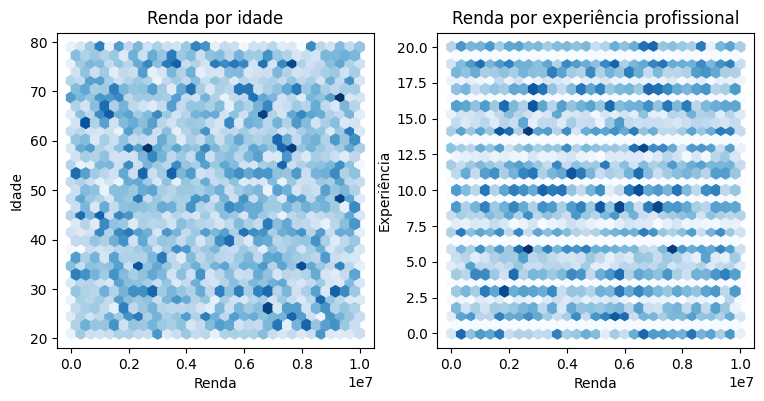

In [6]:
# Extraímos 10% dos dados para amostra
amostra = df.sample(frac=0.10,random_state=342)

# Criamos o molde para os gráficos informativos
fig = plt.figure(figsize=(9,9))
plt.subplot(2,2,1)

# Distribuição de renda por idade
plt.hexbin(x=amostra['Income'], y=amostra['Age'], gridsize=30, cmap='Blues')
plt.xlabel('Renda')
plt.ylabel('Idade')
plt.title('Renda por idade')

# Distribuição de renda por experiência profissional

plt.subplot(2,2,2)
plt.hexbin(x=amostra['Income'], y=amostra['Experience'],gridsize=30,cmap='Blues')
plt.xlabel('Renda')
plt.ylabel('Experiência')
plt.title('Renda por experiência profissional')


Text(0, 0.5, 'Profissão')

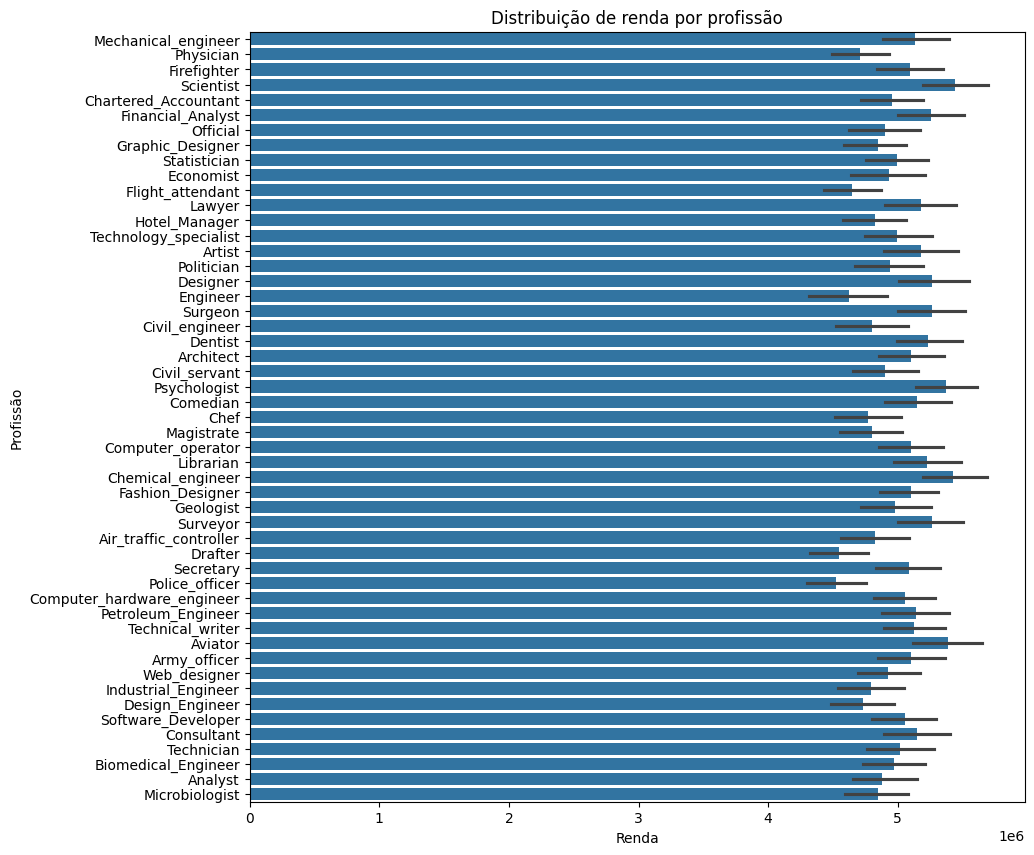

In [7]:
fig = plt.figure(figsize=(10,10))
plt.subplot(1,1,1)

# Distribuição de renda por tipo de profissão
sns.barplot(x='Income', y='Profession', data=amostra, estimator=np.mean)
plt.title('Distribuição de renda por profissão')
plt.xlabel(xlabel='Renda')
plt.ylabel(ylabel='Profissão')

#### 🤖 Machine learning

* Pré-processamento

In [5]:
# Tornando atributos númericos em escalas próximas
scaler = MinMaxScaler()

df['Income_num'] = scaler.fit_transform(df[['Income']])
df['Age_num'] = scaler.fit_transform(df[['Age']])
df['Experience_num'] = scaler.fit_transform(df[['Experience']])
df['CURRENT_JOB_YRS_num'] = scaler.fit_transform(df[['CURRENT_JOB_YRS']])
df['CURRENT_HOUSE_YRS_num'] = scaler.fit_transform(df[['CURRENT_HOUSE_YRS']])
df.drop(columns=['Income','Age', 'Experience', 'CURRENT_JOB_YRS','CURRENT_HOUSE_YRS'], inplace=True)


# 
encoder = LabelEncoder()
df['Married/Single_cat'] = encoder.fit_transform(df[['Married/Single']])
df['House_Ownership_cat'] = encoder.fit_transform(df[['House_Ownership']])
df['Car_Ownership_cat'] = encoder.fit_transform(df[['Car_Ownership']])
df['Profession_cat'] = encoder.fit_transform(df[['Profession']])
df['CITY_cat'] = encoder.fit_transform(df[['CITY']])
df['STATE_cat'] = encoder.fit_transform(df[['STATE']])
df.drop(columns=['Married/Single', 'House_Ownership', 'Car_Ownership','Profession', 'CITY', 'STATE'], inplace=True)

# Divisão em treino e teste
X = df.iloc[:,1:]
y = df[['Risk_Flag']]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33, random_state=42)

print(f'Dados de treinamento: X {X_train.shape}  Y {y_train.shape}')
print(f'Dados de teste: X {X_test.shape} Y {y_test.shape}')

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change t

Dados de treinamento: X (168840, 11)  Y (168840, 1)
Dados de teste: X (83160, 11) Y (83160, 1)


* Tunning de hiperparâmetros

* ###### 🌳Árvores de decisão

In [6]:
param_tree = {
    'criterion': ['gini'],               # mais rápido que 'entropy' ou 'log_loss'
    'splitter': ['best'],                # garante boa divisão com eficiência
    'max_depth': [5, 10],                # limita a complexidade e acelera o treino
    'min_samples_split': [5, 10],        # evita splits desnecessários
    'min_samples_leaf': [2, 4],          # folhas com mais amostras = árvore menor
    'max_features': ['sqrt'],            # reduz custo da busca pelos melhores splits
    'class_weight': [None],              # desativa balanceamento (mais rápido)
    'ccp_alpha': [0.0]                   # sem pruning extra (não mexe no tempo)
}

grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_grid=param_tree, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f'Melhores parâmetros : {grid_search.best_params_}')
print(f'Pontuação : {grid_search.best_score_}')


Melhores parâmetros : {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 5, 'splitter': 'best'}
Pontuação : 0.8795842217484008


* ###### 🌲Floresta aleatória

In [7]:
param_forest = {
    'n_estimators': [100],               # menos árvores, treino muito mais rápido
    'max_depth': [10, 20],               # limita tamanho das árvores (velocidade)
    'min_samples_split': [5, 10],        # menos splits desnecessários
    'min_samples_leaf': [2, 4],          # folhas mais cheias = árvores menores
    'max_features': ['sqrt'],            # menos features no split = treino mais rápido
    'bootstrap': [True],                 # amostragem com reposição, mais eficiente
    'class_weight': [None],              # sem balanceamento = mais rápido
    'ccp_alpha': [0.0]                   # sem pruning extra
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid= param_forest, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f'Melhores parâmetros : {grid_search.best_params_}')
print(f'Pontuação : {grid_search.best_score_}')

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Melhores parâmetros : {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Pontuação : 0.895161099265577


* ###### KNN

In [8]:
param_knn = {
    'n_neighbors': [3, 5],                # menos vizinhos = predição mais rápida
    'weights': ['uniform'],               # peso uniforme evita cálculos extras
    'metric': ['euclidean'],              # distância euclidiana é a mais rápida
    'p': [2]                              # p=2 corresponde à distância euclidiana
}
grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=param_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f'Melhores parâmetros : {grid_search.best_params_}')
print(f'Pontuação : {grid_search.best_score_}')

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Melhores parâmetros : {'metric': 'euclidean', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
Pontuação : 0.8898898365316276


* ###### 📈Regressão logística

In [9]:
param_logreg = {
    'penalty': ['l2'],                  # regularização simples e eficiente
    'C': [1],                           # valor padrão (C=1) evita ajustes desnecessários
    'solver': ['lbfgs'],                # rápido e estável para L2
    'max_iter': [100],                  # iterações suficientes para convergir rápido
    'l1_ratio': [None]                  # desnecessário com penalty='l2'
}

grid_search = GridSearchCV(estimator=LogisticRegression(random_state=42), param_grid=param_logreg, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f'Melhores parâmetros : {grid_search.best_params_}')
print(f'Pontuação : {grid_search.best_score_}')

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Melhores parâmetros : {'C': 1, 'l1_ratio': None, 'max_iter': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Pontuação : 0.8765991471215353


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


* ###### 🧠Redes neurais artificiais

In [ ]:
param_mlp = {
    'hidden_layer_sizes': [(50,), (100,)],
    'activation': ['relu'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001],
    'batch_size': [32],
    'learning_rate': ['adaptive'],
    'max_iter': [200],
    'early_stopping': [True],
    'tol': [1e-4]
}

random_search = RandomizedSearchCV(
    estimator=MLPClassifier(random_state=42),
    param_distributions=param_mlp,
    n_iter=30, 
    cv=3,       
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train, y_train)

print(f'Melhores parâmetros: {random_search.best_params_}')
print(f'Pontuação: {random_search.best_score_}')


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=30. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Melhores parâmetros: {'tol': 0.0001, 'solver': 'adam', 'max_iter': 200, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (100,), 'early_stopping': True, 'batch_size': 32, 'alpha': 0.0001, 'activation': 'relu'}
Pontuação: 0.8767294479981048
